In [ ]:
!pip install transformers torch

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl (176.2 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (99 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21

In [ ]:
!pip install prettytable

In [ ]:
!pip install peft

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.1/314.1 kB 4.2 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manyl

In [ ]:
!pip install torchviz

  Preparing metadata (setup.py) ... done
  Created wheel for torchviz: filename=torchviz-0.0.2-py3-none-any.whl size=4132 sha256=01c64d136a8b39fe1107bac7f57332bc8ac531fe1c10bf499a26847ee3276665
  Stored in directory: /root/.cache/pip/wheels/4c/97/88/a02973217949e0db0c9f4346d154085f4725f99c4f15a87094
Successfully built torchviz


In [ ]:
import numpy as np
import pandas as pd
import time
import torch
from transformers import AutoTokenizer, AutoModel
import csv
import matplotlib.pyplot as plt
#from peft import LoraConfig, get_lora_model
from prettytable import PrettyTable



In [ ]:
import torch

# Check if CUDA (GPU acceleration) is available
if torch.cuda.is_available():
    # Get the number of available GPUs
    print(f"CUDA Device Count: {torch.cuda.device_count()}")

    # Get the current CUDA device index
    print(f"Current CUDA Device Index: {torch.cuda.current_device()}")

    # Get the name of the current CUDA device
    print(f"Current CUDA Device Name: {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("CUDA is not available. Running on CPU.")

CUDA is not available. Running on CPU.


In [ ]:
file_path = '/content/eval.csv'

# Open the CSV file in read mode
with open(file_path, 'r', newline='') as csvfile:
    # Create a CSV reader object
    csv_reader = csv.reader(csvfile)

    # Read the headers from the CSV file
    headers = next(csv_reader)

    # Print the headers
    print("Headers in eval.csv:")
    print(headers)

Headers in eval.csv:
['', 'accession', 'name', 'Full Name', 'taxon', 'sequence', 'function', 'AlphaFoldDB']


In [ ]:
df = pd.read_csv(file_path)
df['seq_len'] = df['sequence'].apply(len)

In [ ]:
from matplotlib.ticker import MultipleLocator

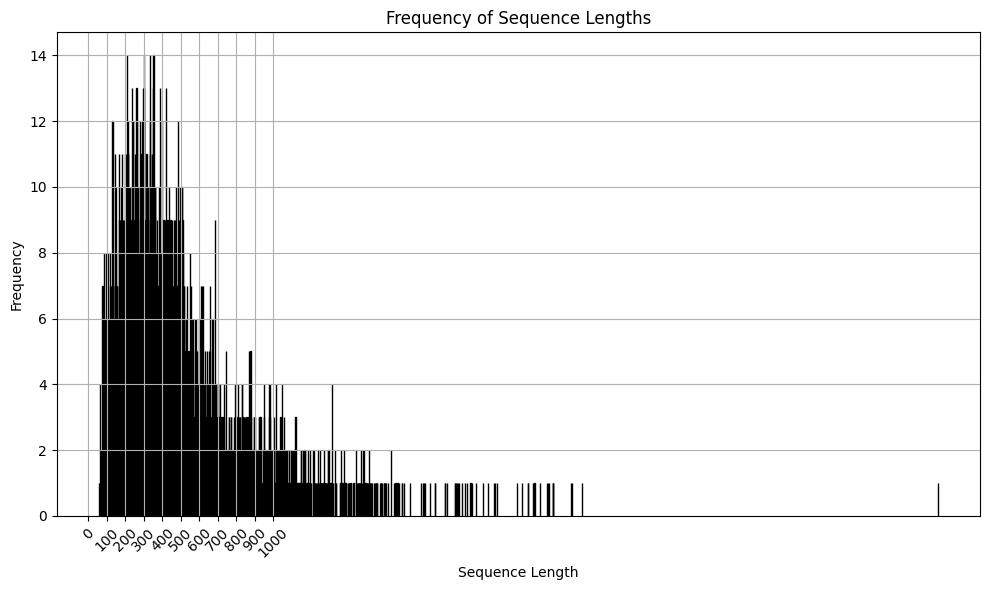

In [ ]:
freq_table = df['seq_len'].value_counts().reset_index()
freq_table.columns = ['Sequence Length', 'Frequency']

# Sort the frequency table by sequence length (optional)
freq_table = freq_table.sort_values(by='Sequence Length')


plt.figure(figsize=(10, 6))
plt.bar(freq_table['Sequence Length'], freq_table['Frequency'], color='skyblue', edgecolor='black')
plt.title('Frequency of Sequence Lengths')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.grid(True)
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility

plt.xticks(range(0, 1001, 100))

plt.tight_layout()
plt.show()


In [ ]:
protein_sequences_len_500 = df[df['seq_len'] == 500]['sequence'].tolist()


In [ ]:
print(protein_sequences_len_500)

['MKNQDLVEYLRSCGVCEICQLRYLKARGAEYRNINETLQKLDVKLNENVENEELVISEGSQPSKRARLGVCSTCLGLFSKDFQNELLSSILASDFAKYDCQKIVLAICLPMSLQLRQLAMWFALRRRFGPSIDENNPPDVPIKEAVKLILHPIICEKLAKVYDANGLMINIDLTHSLEGEEVEKLVKLNKEAFPAKASHQKRIEISRGLLEKQYQPSKVKAETYEKYFQIPCSNVEESIKLTSIDLQGPLICVAGRYRKLSRELSHTPWILNGQRLMEDSIEEIIIRHVGPHFTEKLGKITFMSSGREDVDVRCLGKGRPFVLEIPNAKRSCLTKDEAFAMERAVDASGMVSIHHLQVVPREELTHIKTGEEQKKKFYRALCALQEPVSVKILEQLQISASFNIQQKTPIRVLHRRPLHTRPRTIYSVTAKVHRGNPKALIIDIVTQAGTYIKELVHGEFGRTTPSLSSIIGKPMDIQALDVVGIDLDWPHEVDNSKHKE', 'MEVASLYRRVLPSPPAVEFASAEGKRLFAEALQGGTMEGFFNLISYFQTQSEPAFCGLASLSVVLNALAIDPGRPWKGPWRWFDESMLDCCEPLHKVKAEGITFGKVVCLAHCAGARVQSFRADQTTIHDFRAHLTRCASSQDCHLISSYHRSPFKQTGTGHFSPIGGYHAEKDMALILDVARFKYPPHWVPLTLLWDAMNTTDEATGLLRGFMLVSRRSSAPSLLYTVSCGHGSWKSMAKYCVEDVPNLLKDESLDNVTTLLSRLVESLPANAGDLIKCVIEVRRKEEGESSLSKEEKERLFLKEKVLQQIRDTDLFRVVHELQYPKGLCGSCSSSSDEDSLAEIAATVCCQGAAFLSGNLVSRDGFCCRETCIKCIEANGDGLKTVISGTVVSKGNEQAVDLLLPTSSSKTSLCNSNLKSKIVKYPSSTDVLTVLLLVLQPNTWLGIKDENVKAEFQSLVSTDNLPDLLKQEILHLRRQLHYLAGCKGQEAC

Loading the Pretrained esm2_t12_35M_UR50D encoder.

In [ ]:
model_name = "facebook/esm2_t12_35M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/778 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/136M [00:00<?, ?B/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
protein_sequence = 'MKNQDLVEYLRSCGVCEICQLRYLKARGAEYRNINETLQKLDVKLNENVENEELVISEGSQPSKRARLGVCSTCLGLFSKDFQNELLSSILASDFAKYDCQKIVLAICLPMSLQLRQLAMWFALRRRFGPSIDENNPPDVPIKEAVKLILHPIICEKLAKVYDANGLMINIDLTHSLEGEEVEKLVKLNKEAFPAKASHQKRIEISRGLLEKQYQPSKVKAETYEKYFQIPCSNVEESIKLTSIDLQGPLICVAGRYRKLSRELSHTPWILNGQRLMEDSIEEIIIRHVGPHFTEKLGKITFMSSGREDVDVRCLGKGRPFVLEIPNAKRSCLTKDEAFAMERAVDASGMVSIHHLQVVPREELTHIKTGEEQKKKFYRALCALQEPVSVKILEQLQISASFNIQQKTPIRVLHRRPLHTRPRTIYSVTAKVHRGNPKALIIDIVTQAGTYIKELVHGEFGRTTPSLSSIIGKPMDIQALDVVGIDLDWPHEVDNSKHKE'
inputs = tokenizer(protein_sequence, add_special_tokens=True, truncation=True, max_length=1021, padding='max_length',return_tensors="pt")

In [ ]:
print(inputs)

{'input_ids': tensor([[ 0, 20, 15,  ...,  1,  1,  1]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0]])}


TypeError: 'method' object is not subscriptable

In [ ]:
with torch.no_grad():
    outputs = model(**inputs)
    encoder_outputs = outputs.last_hidden_state

In [ ]:
encoder_outputs.shape

torch.Size([1, 1021, 480])

In [ ]:
from transformers import AutoConfig

In [ ]:
model_name = "facebook/esm2_t12_35M_UR50D"
config = AutoConfig.from_pretrained(model_name)
embedding_size = config.hidden_size
print(embedding_size)

480


/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel

# Load tokenizer and model for ESM-2
tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t12_35M_UR50D")
model = AutoModel.from_pretrained("facebook/esm2_t12_35M_UR50D")  # Put the model on GPU if available

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
def encode_sequences(sequences):
    embeddings = []
    for sequence in sequences:
        inputs = tokenizer(sequence, add_special_tokens=True, truncation=True, max_length=1021, padding='max_length',return_tensors="pt").to(model.device)
        with torch.no_grad():
            outputs = model(**inputs)

        # Get the embeddings from the last layer (CLS token)
        sequence_embedding = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
        embeddings.append(sequence_embedding)

    return embeddings

In [ ]:
sequences = df['sequence'][:100]

In [ ]:
len(sequences)

100

In [ ]:
len(sequences)

2

In [ ]:
encoded_embeddings = encode_sequences(sequences)

In [ ]:
len(encoded_embeddings)

2

In [ ]:
tokenizer(df['sequence'][0])

In [ ]:
print(encoded_embeddings[0])

[[-1.17969308e-02 -1.96055640e-02  9.35442597e-02 -1.50040194e-01
  -5.88053614e-02 -2.76812986e-02  2.07536090e-02 -5.49912378e-02
  -2.80936889e-04  2.07347907e-02 -4.32357416e-02  5.55204228e-02
   5.09257205e-02 -2.36525331e-02 -3.47065404e-02 -1.09737396e-01
  -2.23231744e-02  1.59342781e-01 -7.95508847e-02 -9.59827080e-02
  -8.31270069e-02  2.50668880e-02  1.84149500e-02 -9.08651799e-02
  -1.11685157e-01  8.70462954e-02  8.78347456e-02  3.10256649e-02
  -1.28956065e-01  4.18533124e-02 -7.79449344e-02  1.00231022e-02
   1.80130843e-02  5.03088981e-02 -2.51404494e-02 -1.03216939e-01
   1.34166647e-02 -1.33511974e-02 -7.10734650e-02  5.12722805e-02
   2.12596878e-02 -1.07968738e-02 -1.14023134e-01 -1.27208248e-01
  -2.23314408e-02  9.12106559e-02  6.01788235e+00  1.15991859e-02
  -1.84819251e-01 -1.60677303e-02  1.56191036e-01 -5.11803944e-03
  -1.24982424e-01  1.66738644e-01  4.33540195e-02  8.75139758e-02
   4.96860892e-02  9.21888684e-04 -7.53335608e-03 -6.48771180e-03
   3.70286

# Creating Encoders for Protein Sequences

# Tokenization and Attention Mask for Protein Description

In [ ]:
from transformers import GPT2Tokenizer


In [ ]:
df = pd.read_csv('/content/eval.csv')


In [ ]:
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
descriptions = df['function'].tolist()


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

In [ ]:
tokenizer.pad_token = tokenizer.eos_token


In [ ]:
def batch_tokenize(texts):
    # Tokenize inputs in batch
    inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True)
    attention_masks = inputs['attention_mask']
    return inputs, attention_masks

In [ ]:
batch_size = 8  # You can adjust the batch size based on your system's memory
num_samples = len(df)
tokenized_texts = []
attention_masks = []

for i in range(0, num_samples, batch_size):
    batch = df['function'][i:i+batch_size].tolist()
    tokenized_batch, mask_batch = batch_tokenize(batch)
    tokenized_texts.extend(tokenized_batch['input_ids'])
    attention_masks.extend(mask_batch)


In [ ]:
import pickle

In [ ]:
with open('tokenized_data_eval.pkl', 'wb') as f:
    pickle.dump((tokenized_texts, attention_masks), f)


In [ ]:
np.save('description_input_ids.npy', input_ids)
np.save('description_attention_masks.npy', attention_masks)

# Pre-encode Training Protein sequences and Description



In [ ]:
class ProteinDataset(torch.utils.data.Dataset):
    def __init__(self, encoded_sequences_file, tokenized_data_file):
        # Load encoded sequences from the .npy file
        self.encoded_sequences = np.load(encoded_sequences_file)

        # Load tokenized descriptions and attention masks from the pickle file
        with open(tokenized_data_file, 'rb') as f:
            self.description_input_ids, self.description_attention_masks = pickle.load(f)

    def __len__(self):
        return len(self.encoded_sequences)

    def __getitem__(self, idx):
        return {
            'sequence_embedding': torch.tensor(self.encoded_sequences[idx], dtype=torch.float),
            'description_input': torch.tensor(self.description_input_ids[idx], dtype=torch.long).squeeze(),
            'description_attention_mask': torch.tensor(self.description_attention_masks[idx], dtype=torch.long).squeeze()
        }

In [ ]:
encoded_sequences_file = '/content/train_ESM2_t12_35M_embeddings.npy'
tokenized_data_file = 'tokenized_data.pkl'

# Create the dataset

In [ ]:
dataset = ProteinDataset(encoded_sequences_file, tokenized_data_file)

KeyboardInterrupt: 

In [ ]:
train_loader = torch.utlils.data.DataLoader(dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)

NameError: name 'torch' is not defined



```
# This is formatted as code
```

# Decoder Model (GPT-2 Base)

In [ ]:
import torch.nn as nn
from transformers import GPT2LMHeadModel, GPT2Config, GPT2Tokenizer, AutoTokenizer, AutoModel

#Loading GPT-2 Tokenizer and Model

gpt2_config = GPT2Config.from_pretrained('gpt2')
gpt2_model = GPT2LMHeadModel.from_pretrained('gpt2', config = gpt2_config)
tokenizer_gpt2 = GPT2Tokenizer.from_pretrained('gpt2')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
#ESM2-GPT2
class customDecoder(nn.Module):
  def __init__(self,gpt2_model, protein_embedding_size):
    super(customDecoder, self).__init__()
    self.gpt2 = gpt2_model

    self.multi_head_attention = nn.MultiheadAttention(embed_dim = gpt2_config.hidden_size, num_heads = gpt2_config.num_attention_heads)

    self.projection_layer = nn.Linear(protein_embedding_size, gpt2_config.hidden_size)

    self.layer_norm = nn.LayerNorm(gpt2_config.hidden_size)

    self.lm_head = nn.Linear(gpt2_config.hidden_size, gpt2_config.vocab_size)

  def forward(self, input_ids, protein_embedding, attention_mask = None):

    projected_protein = self.projection_layer(protein_embedding)

    cross_attention_output, _ = self.multi_head_attention(projected_protein.unsqueeze(0),input_ids.unsqueeze(0), input_ids.unsqueeze(0))

    combined_embeddings = self.layer_norm(cross_attention_output + self.gpt2.transformer.wte(input_ids))

    outputs = self.gpt2(inputs_embeds =  combined_embeddings, attention_mask = attention_mask)

    return outputs

In [ ]:
#Initializing decoder model
custom_decoder = customDecoder(gpt2_model = gpt2_model, protein_embedding_size = 480)


In [ ]:
table = PrettyTable(["Parameter Name", "Shape", "Requires Grad"])

In [ ]:
for name, param in custom_decoder.named_parameters():
        table.add_row([name, list(param.shape), param.requires_grad])


print(table)

+------------------------------------------+--------------+---------------+
|              Parameter Name              |    Shape     | Requires Grad |
+------------------------------------------+--------------+---------------+
|       gpt2.transformer.wte.weight        | [50257, 768] |      True     |
|       gpt2.transformer.wpe.weight        | [1024, 768]  |      True     |
|     gpt2.transformer.h.0.ln_1.weight     |    [768]     |      True     |
|      gpt2.transformer.h.0.ln_1.bias      |    [768]     |      True     |
| gpt2.transformer.h.0.attn.c_attn.weight  | [768, 2304]  |      True     |
|  gpt2.transformer.h.0.attn.c_attn.bias   |    [2304]    |      True     |
| gpt2.transformer.h.0.attn.c_proj.weight  |  [768, 768]  |      True     |
|  gpt2.transformer.h.0.attn.c_proj.bias   |    [768]     |      True     |
|     gpt2.transformer.h.0.ln_2.weight     |    [768]     |      True     |
|      gpt2.transformer.h.0.ln_2.bias      |    [768]     |      True     |
|   gpt2.tra

In [ ]:
from torchviz import make_dot

outputs = custom_decoder(input_ids, protein_embedding)

dot = make_dot(outputs, params=dict(custom_decoder.named_parameters()))
dot.format = 'png'
dot.render('custom_decoder_model')

NameError: name 'outputs' is not defined

In [ ]:
#Training on GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

custom_decoder.to(device)


In [ ]:
optimizer  = torch.optim.AdamW(custom_decoder.parameters(), lr = 1e-5)
criterion  = nn.CorssEntropyLoss(ignore_index = tokenizer_gpt2.pad_token_id)

# Fine Tuning ESM-GPT2

In [ ]:
def fine_tune_model(model, train_loader, optimizer, criterion, device = 'cuda'):
  model.train()
  for batch in train_loader:
    sequence_embedding = batch['sequence_embedding'].to(device)
    description_input_ids = batch['description_input_ids'].to(device)
    desciption_attention_mask = batch['description_attention_mask'].to(device)

    optimizer.zero_grad()

    outputs = model(input_ids = description_input_ids, protein_embeddings = sequence_embedding, attention_mask = description_attention_mask)
    logits = outputs.logits


    loss = criterion(logits.view(-1, logits.shape[-1]), description_input_ids.view(-1))

    loss.backward()
    optmizer.step()

In [ ]:
#Saving the Fine Tuned Model
torch.save(custom_decoder.state_dict(), 'custom_decoder.pt')